<a href="https://colab.research.google.com/github/narayan-dnv/MLE-CS1/blob/main/CS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d dubradave/hospital-readmissions -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/dubradave/hospital-readmissions
License(s): other
100% 286k/286k [00:00<00:00, 84.2MB/s]



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./data/hospital_readmissions.csv")
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [5]:
df['readmitted'] = df['readmitted'].map({'no': 0, 'yes': 1})

In [6]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [7]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [12]:
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.6458628481747726


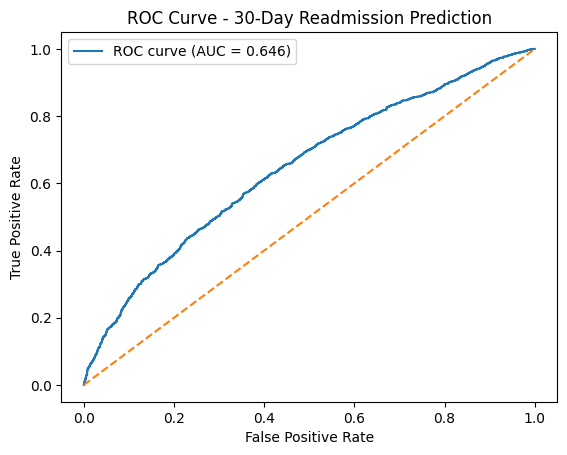

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Readmission Prediction")
plt.legend()
plt.show()

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2098  551]
 [1415  936]]


In [15]:
tn, fp, fn, tp = cm.ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 2098
False Positives: 551
False Negatives: 1415
True Positives: 936


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.79      0.68      2649
           1       0.63      0.40      0.49      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.58      5000
weighted avg       0.61      0.61      0.59      5000



In [17]:
cost_fn_per_case = 15000
cost_fp_per_case = 1500

total_fn_cost = fn * cost_fn_per_case
total_fp_cost = fp * cost_fp_per_case

print("Estimated cost of False Negatives (missed readmissions):", total_fn_cost)
print("Estimated cost of False Positives (unnecessary interventions):", total_fp_cost)
print("Total estimated cost:", total_fn_cost + total_fp_cost)

Estimated cost of False Negatives (missed readmissions): 21225000
Estimated cost of False Positives (unnecessary interventions): 826500
Total estimated cost: 22051500


In [18]:
coeffs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coeffs

,feature,coefficient
6,n_inpatient,0.452540
7,n_emergency,0.213380
5,n_outpatient,0.154736
15,diabetes_med,0.104810
3,n_procedures,-0.080169
0,age,0.060759
9,diag_1,-0.058048
1,time_in_hospital,0.045491
8,medical_specialty,-0.044253
2,n_lab_procedures,0.035724
